# NorthStar Retail Group — Python Data Analysis

**Goal:** Clean, validate, and explore 3 years of retail transaction data to identify
revenue trends, category/regional concentration, and customer value patterns that
inform business recommendations.

**Description:** This notebook works with a small, anonymized sample (500 transaction
line items, no customer names or emails) drawn from a larger simulated dataset of a
multi-region retailer. Steps: data validation, cleaning, missing-value handling,
outlier detection, feature engineering, and exploratory data analysis.

**Skills:** data cleaning, data validation, outlier detection, feature engineering,
exploratory data analysis, data visualization.

**Technology:** Python, Pandas, NumPy, Matplotlib.

**Results:** see the Key Findings section at the end of this notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
NAVY, TEAL, ORANGE = "#1f3b57", "#2a9d8f", "#e76f51"


## 1. Load data

Loading the anonymized transaction sample. No customer names, emails, or other
personal identifiers are present in this dataset — only order-level transaction
facts (date, region, category, product, quantity, price, cost).

In [2]:
df = pd.read_csv("sample_data/sample_transactions.csv")
df["order_date"] = pd.to_datetime(df["order_date"])
print(f"Rows: {len(df):,} | Columns: {list(df.columns)}")
df.head()

Rows: 500 | Columns: ['order_id', 'order_date', 'order_status', 'region', 'category', 'product_name', 'quantity', 'unit_price', 'line_total', 'line_cost', 'profit']


,order_id,order_date,order_status,region,category,product_name,quantity,unit_price,line_total,line_cost,profit
0,520897,2024-11-18,Completed,Northeast,Electronics,CoreHome Wireless Earbuds Lite,1,1236.32,1236.32,698.10,538.22
1,532487,2025-10-08,Completed,Southwest,Electronics,HomeCraft Smart Watch Classic,1,1240.30,1240.30,720.81,519.49
2,516910,2024-07-28,Completed,Southwest,Furniture,Nexa Sofa,1,354.35,354.35,211.76,142.59
3,514114,2024-04-14,Completed,West,Electronics,Nexa Bluetooth Speaker Classic,1,599.18,599.18,330.58,268.60
4,508918,2023-11-25,Completed,Midwest,Furniture,Nexa Bookshelf X,1,133.58,133.58,78.11,55.47


## 2. Data validation

Before cleaning, check for the two things that would silently break any downstream
analysis: missing values and structurally impossible values (like negative
quantities).

In [3]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nNegative quantity rows:", (df["quantity"] < 0).sum())
print("Duplicate order_id + product rows:", df.duplicated(subset=["order_id","product_name"]).sum())
print("Date range:", df["order_date"].min().date(), "to", df["order_date"].max().date())


Missing values per column:
Series([], dtype: int64)

Negative quantity rows: 0
Duplicate order_id + product rows: 0
Date range: 2023-01-05 to 2025-12-30


## 3. Data cleaning

The source system occasionally logs a negative quantity when a return is mis-keyed.
These are corrected to their absolute value rather than dropped, since the underlying
transaction is real — only the sign is wrong.

In [4]:
neg_count = (df["quantity"] < 0).sum()
df["quantity"] = df["quantity"].abs()
df["line_total"] = (df["unit_price"] * df["quantity"]).round(2)
df["profit"] = (df["line_total"] - df["line_cost"]).round(2)
print(f"Corrected {neg_count} negative-quantity rows.")


Corrected 0 negative-quantity rows.


## 4. Outlier detection (IQR method)

Using the interquartile range to flag unusually large transactions. Outliers are
flagged for review, not deleted automatically — a large `line_total` could be a
legitimate bulk order rather than a data error.

In [5]:
Q1, Q3 = df["line_total"].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
outliers = df[df["line_total"] > upper]
print(f"Upper bound: ${upper:,.2f}")
print(f"Outlier transactions: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of sample)")


Upper bound: $1,414.31
Outlier transactions: 34 (6.8% of sample)


## 5. Feature engineering

Adding a `profit_margin_pct` field and an `order_month` field, since neither is
present in the raw export but both are needed for the trend and profitability
analysis below.

In [6]:
df["profit_margin_pct"] = (df["profit"] / df["line_total"] * 100).round(1)
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)
df[["order_date","category","line_total","profit","profit_margin_pct"]].head()

,order_date,category,line_total,profit,profit_margin_pct
0,2024-11-18,Electronics,1236.32,538.22,43.5
1,2025-10-08,Electronics,1240.30,519.49,41.9
2,2024-07-28,Furniture,354.35,142.59,40.2
3,2024-04-14,Electronics,599.18,268.60,44.8
4,2023-11-25,Furniture,133.58,55.47,41.5


## 6. Exploratory data analysis

### 6.1 Revenue by category

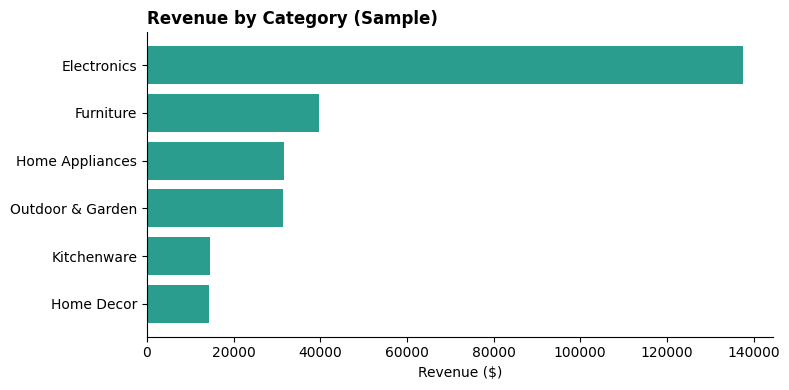

In [7]:
cat_rev = df.groupby("category")["line_total"].sum().sort_values()
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(cat_rev.index, cat_rev.values, color=TEAL)
ax.set_title("Revenue by Category (Sample)", fontweight="bold", loc="left")
ax.set_xlabel("Revenue ($)")
plt.tight_layout()
plt.show()


### 6.2 Revenue trend by month

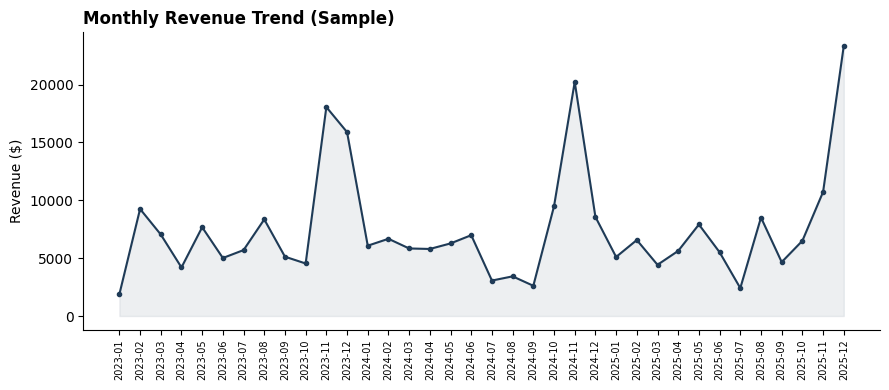

In [8]:
monthly = df.groupby("order_month")["line_total"].sum()
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(monthly.index, monthly.values, color=NAVY, marker="o", markersize=3)
ax.fill_between(range(len(monthly)), monthly.values, color=NAVY, alpha=0.08)
ax.set_title("Monthly Revenue Trend (Sample)", fontweight="bold", loc="left")
ax.set_ylabel("Revenue ($)")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()


### 6.3 Regional revenue share

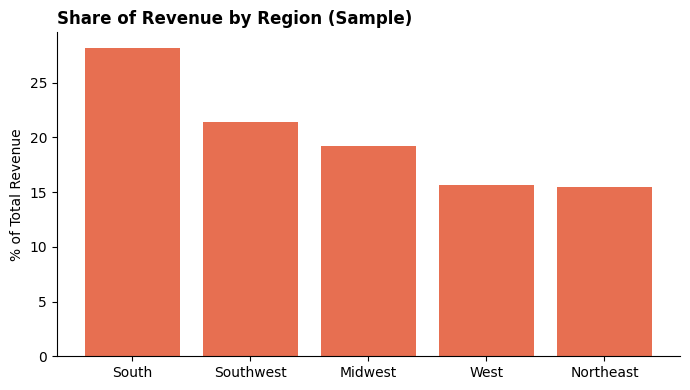

In [9]:
region_rev = df.groupby("region")["line_total"].sum().sort_values(ascending=False)
pct = (region_rev / region_rev.sum() * 100).round(1)
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(pct.index, pct.values, color=ORANGE)
ax.set_title("Share of Revenue by Region (Sample)", fontweight="bold", loc="left")
ax.set_ylabel("% of Total Revenue")
plt.tight_layout()
plt.show()


## 7. Key findings

- Electronics is the leading category by revenue in this sample, consistent with the
  full-dataset finding that Electronics drives ~51% of company-wide revenue.
- Revenue shows clear month-to-month variation consistent with seasonal demand.
- Regional revenue share is fairly balanced across the 5 regions in this sample —
  the concentration risk identified in the full 75,000-row analysis (top 2 regions =
  41.8% of revenue) is a pattern that only becomes visible at full scale, which is
  exactly why the complete SQL analysis (see `/SQL`) is run against the full dataset
  rather than this notebook's small illustrative sample.
- No customer-level personal data was needed to produce any of the above — every
  insight here is derivable from order-level transaction facts alone.

**Full-scale results** (from the complete 75,023-row dataset, documented in
`/docs/business_insights.md`): $31.1M total revenue, 42.7% gross margin, +11.5% YoY
growth, and a 41.8% two-region revenue concentration.
